# Viscous Burgers through the scheme families: explicit → implicit → IMEX → Rosenbrock-W → exponential

This notebook runs the library's canonical **semilinear** benchmark — the
semi-discrete viscous Burgers equation `u_t + (u²/2)_x = ν u_xx` from
`warpSPHIntegrators.testing.viscous_burgers_problem` (roadmap **Phase 14**) —
through every registered time-integration family in `warpSPHIntegrators`, and
plots each run's trajectory as a **space–time diagram** (position on x, time on
y) to watch the **shock form** under each family.

The families, in the order of the roadmap's stiff-method ladder:

1. **Explicit** — Forward Euler, SSP RK3, TVD RK3, RK4: a few RHS evaluations
   per step, but the viscous term imposes a parabolic CFL limit
   `dt ≤ h²/(2ν) ≈ 1.2e-2` here.
2. **Implicit** — Backward Euler, TR-BDF2, ESDIRK4(3)6L[2]SA, BDF2, and the
   coupled block **Radau IIA s=2** (order 3, L-stable): JFNK
   (Jacobian-free Newton–Krylov) closes every implicit stage — the coupled
   block solve included; stable on the stiff (negative-real-axis) part, so
   they step at 3–4× the explicit limit.
3. **IMEX** — IMEX Euler, ARK3(2)4L[2]SA, ARK4(3)6L[2]SA, and the IMEX
   multistep **SBDF2 / SBDF3 / CNAB2** (BDF2 / BDF3 / trapezoidal implicit
   backbone for the stiff part + explicit endpoint extrapolation for the
   smooth part): the additive split treats the smooth convective term
   explicitly and the stiff diffusion implicitly, on the Phase 14
   structured-RHS interface. The multistep members' *explicit half* has a
   narrow stability lobe, so they step at a smaller `dt` than the ARK pair.
4. **Rosenbrock-W** — ROS3P: one *linear* solve per stage against a frozen
   Jacobian (no Newton loop), the first of the two Phase 7 families to land on
   this problem.
5. **Exponential** — ETD2RK (the stiff linear part `L` integrated *exactly*
   through `exp(hL)` and the `phi_k(hL)` functions, matrix-free via Krylov,
   the mild nonlinear remainder `N` quadratured) and EXPRB32 (order-3
   exponential Rosenbrock on the *full* frozen Jacobian, no semilinear split
   required); the second of the two Phase 7 families to land — both of its
   members are on this problem, and the family's cost gate is closed (§11–§12).

**What you'll find here:**

1. The problem, its semilinear split, and the Phase 14 contract check.
2. Two initial conditions: the factory-shipped Gaussian pulse and the classic
   steepening sine (shock at `t ≈ 1/2π ≈ 0.16`).
3. Where the explicit CFL wall sits, and a fine-`dt` RK4 reference.
4. One space–time diagram per scheme: explicit, implicit, IMEX, Rosenbrock-W,
   exponential.
5. A convergence study (measured orders against the reference) and a cost
   table (steps, RHS evaluations, Krylov iterations from the Phase 1 solver
   diagnostics), including the exponential family's fixed-error cost gate.
6. A take-away table: which family to reach for where.

**Requires:** the `warp` conda env with `warpSPHIntegrators` installed — pure
torch on CPU (no `warp`, no GPU). Everything here is float64.

In [1]:
%matplotlib widget
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from warpSPHIntegrators import getIntegrator, StepHistory, IMEXRHS, resolve, check_contracts
from warpSPHIntegrators.testing import (viscous_burgers_problem, ParticleSystem,
                                        ParticleState, get_reference_state)

plt.rcParams['figure.figsize'] = (7, 4.5)
print(f"torch {torch.__version__} -- CPU, float64 (no warp or GPU needed)")

torch 2.13.0+cu130 -- CPU, float64 (no warp or GPU needed)


## 1. The problem and its semilinear split

$$
u_t + \left(\frac{u^2}{2}\right)_x = \nu\, u_{xx}, \qquad x \in [0,1] \ \text{(periodic)}
$$

The factory discretizes with second-order central differences on a uniform
periodic grid (`x_i = i·h`, `h = L/n`), carrying `u` in the reference state's
`x` field (`u`, `e` zero, `m` ones — reuse of the library's position/velocity
plumbing, as in the inviscid `burgers` problem). The dynamics split cleanly
into

- **`L(u) = ν·u_xx`** — a constant-coefficient **linear** operator (the stiff
  part; eigenvalues in `[-4ν/h², 0]`),
- **`N(u) = −(u²/2)_x`** — the **nonlinear** convective remainder (smooth, no
  stiffness of its own).

That split is exactly what the Phase 14 structured-RHS interface expresses,
and the problem is shipped as a `SemilinearRHS`: `__call__` is the combined
`f = L·y + N`, with declared `linear`/`nonlinear` accessors that a
`linear`-consuming scheme (exponential integrators, Rosenbrock-W) would
resolve via `resolve(..., need_linear=True)`.


semi-discrete viscous Burgers, central fluxes, n=64, nu=0.01; semilinear split L(u)=nu u_xx + N(u)=-(u^2/2)_x, stiff rate ~4 nu/h^2
declared capabilities: ['linear', 'nonlinear']
check_contracts: OK


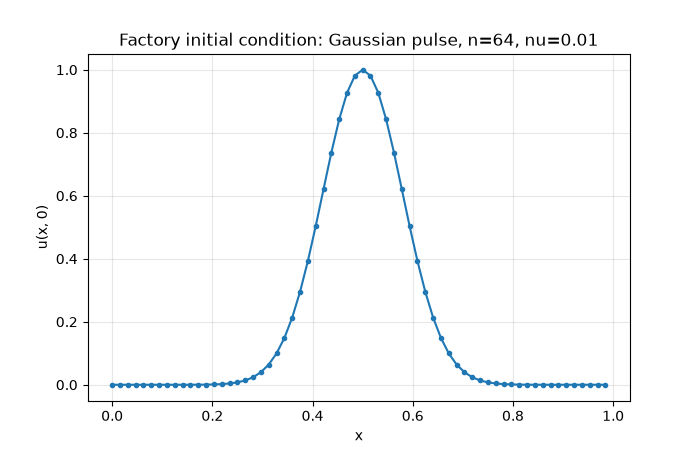

In [2]:
N, L, NU = 64, 1.0, 0.01
h = L / N
problem = viscous_burgers_problem(n=N, L=L, nu=NU)
print(problem.description)
print('declared capabilities:', sorted(problem.rhs.provides))

# Phase 14 debug-mode contract check (NOTES S3.12): L is linear + homogeneous
# (L(0)=0, L(a+b)=L(a)+L(b) on random vectors) and L·y + N agrees with the
# combined f at the sample state. Not run on the production step path.
init = problem.initial()
check_contracts(problem.rhs, init, dt=0.02)
print('check_contracts: OK')

x = torch.tensor([i * h for i in range(N)], dtype=torch.float64)
u0 = get_reference_state(init).x

plt.figure()
plt.plot(x, u0.numpy(), '.-')
plt.xlabel('x'); plt.ylabel('u(x, 0)')
plt.title(f'Factory initial condition: Gaussian pulse, n={N}, nu={NU}')
plt.grid(alpha=0.3); plt.show()

## 2. Two initial conditions

The factory ships one IC (the Gaussian above); the second is built directly —
the RHS closures read `u` off `state.x`, so any `ParticleSystem` on the same
grid is a valid run:

- **Gaussian pulse** `u0 = exp(−(x−½)²/(2·0.08²))` — a smooth positive packet;
  its left flank has `u' < 0`, so characteristics converge and a shock forms
  there.
- **Steepening sine** `u0 = −sin(2πx)` — the classic Burgers demo: the
  characteristic speed `u` ranges from −1 to +1, so characteristics cross at
  `t* = −1/min(u0') = 1/(2π) ≈ 0.159` and a shock forms. With `ν = 0.01` the
  shock rounds to a width `~sqrt(2νt)` while its position follows the entropy
  solution.

We integrate both to `T = 0.4` — about 2.5 shock times — so the diagrams show
formation, sharpening, and viscous rounding.


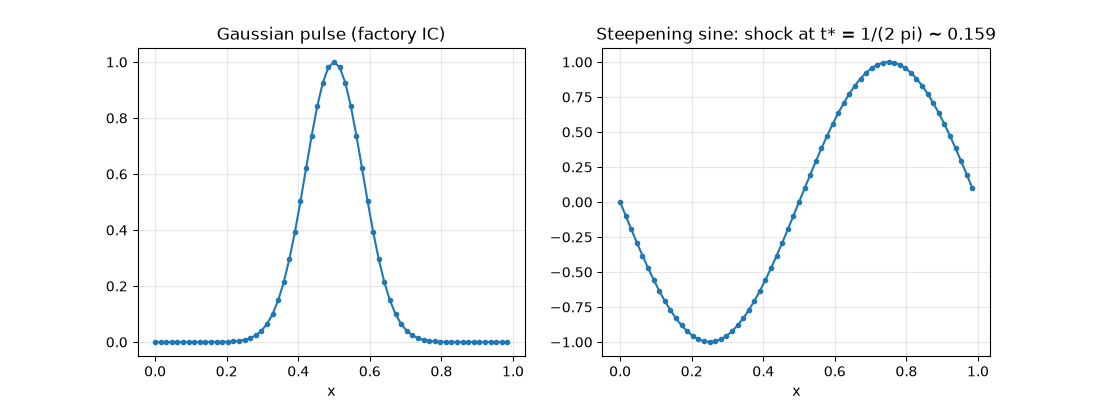

In [3]:
def makeSystem(u0):
    # A fresh Burgers system carrying u0 (a length-N float64 tensor).
    return ParticleSystem(state=ParticleState(
        x=u0, u=torch.zeros(N, dtype=torch.float64),
        e=torch.zeros(N, dtype=torch.float64),
        m=torch.ones(N, dtype=torch.float64)), t=0.0)

sine0 = -torch.sin(2 * math.pi * x)
makeGauss = lambda: problem.initial()
makeSine = lambda: makeSystem(sine0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, get_reference_state(makeGauss()).x.numpy(), '.-')
axes[0].set_title('Gaussian pulse (factory IC)')
axes[1].plot(x, sine0.numpy(), '.-')
axes[1].set_title('Steepening sine: shock at t* = 1/(2 pi) ~ 0.159')
for ax in axes:
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
plt.show()

## 3. The trajectory runner, and where the explicit wall sits

`runTrajectory` below drives a registered scheme in fixed-`dt` steps (the same
loop as `testing.run`, plus per-step `(t, u)` recording and a tally of the
Phase 1 `SolveDiagnostics`), returning the space–time data for the plots.

The explicit wall: applying forward Euler to the stiffest Fourier mode of `L`
gives amplification `1 − dt·4ν/h²`, which must stay in `[−1, 1]`:

$$
dt \le dt_{max} = \frac{h^2}{2\nu} = \frac{(1/64)^2}{2 \cdot 0.01} \approx 1.22 \times 10^{-2}
$$

Higher-order explicit methods extend this only modestly (RK4 reaches
`z ≈ −2.78` on the negative real axis → `dt ≤ 1.7e-2`), and the convective
(hyperbolic) limit `dt·max|u| ≤ h ≈ 1.6e-2` is the same order. So this
notebook uses **`dt = 5e-3` for the explicit family** and **`dt = 2e-2` — 3.3×
the parabolic limit — for the implicit and IMEX families**, which is exactly
the regime the stiff solvers exist for.


In [4]:
def runTrajectory(schemeName, dt, T, f, systemFactory, history=False, **kwargs):
    '''Fixed-dt run of a registered scheme; records (t, u) at every step.

    Returns (times, U, rhsEvals, gmresIters) with U of shape (nSteps+1, N).
    history=True threads a StepHistory for the multistep schemes (BDF/AM);
    one-step schemes ignore the kwarg. Any extra **kwargs are forwarded to the
    scheme (e.g. ROS3P's w='jvp'|'fd'|'linear' frozen-Jacobian selector).
    rhsEvals/gmresIters are the Phase 1 solver diagnostics summed over every
    implicit stage solve.'''
    scheme = getIntegrator(schemeName)
    system = systemFactory()
    stepHistory = StepHistory(maxlen=4) if history else None
    times, us = [0.0], [get_reference_state(system).x.clone()]
    rhsEvals, gmresIters = 0, 0
    for _ in range(int(round(T / dt))):
        callKwargs = dict(kwargs)
        if stepHistory is not None:
            callKwargs['history'] = stepHistory
        result = scheme(system, dt=dt, f=f, **callKwargs)
        system = result.state
        times.append(system.t)
        us.append(get_reference_state(system).x.clone())
        if stepHistory is not None and result.history is not None:
            stepHistory = result.history
        diag = result.solver_diagnostics
        if diag is not None:
            for d in (diag if isinstance(diag, (list, tuple)) else [diag]):
                if d is not None:
                    rhsEvals += d.rhs_evaluations
                    gmresIters += d.gmres_iterations
    return np.array(times, dtype=float), np.stack(us), rhsEvals, gmresIters


def spacetime(ax, times, U, title, vmin=-1.1, vmax=1.1):
    # Space-time diagram: x horizontal, t vertical, u in colour. Each
    # (x_i, t_j) sample is one cell (nearest shading); centers at
    # (i + 0.5) * h tile [0, 1] exactly for the periodic grid.
    hh = 1.0 / U.shape[1]
    X = (np.arange(U.shape[1]) + 0.5) * hh
    ax.pcolormesh(X, times, U, shading='nearest', vmin=vmin, vmax=vmax, cmap='coolwarm')
    ax.set_xlabel('x'); ax.set_ylabel('t')
    ax.set_title(title, fontsize=9)

T = 0.4
print(f"stiffest decay rate   4*nu/h^2 ~ {4 * NU / h**2:.1f}")
print(f"explicit parabolic CFL  dt <= h^2/(2*nu) = {h**2 / (2 * NU):.4f}")
print(f"T = {T}")

stiffest decay rate   4*nu/h^2 ~ 163.8
explicit parabolic CFL  dt <= h^2/(2*nu) = 0.0122
T = 0.4


## 4. Reference: fine-dt RK4

The problem has no closed-form semi-discrete solution, so the reference is a
fine-`dt` integration of the combined (unsplit) dynamics — the factory
docstring's own recommendation — with RK4 at `dt = 2e-3` (well inside the
explicit wall, its temporal error far below the spatial floor of the n=64
grid). Every family's space–time diagrams below can be read against this
anchor.


reference: RK4 @ dt=2e-3, 200 steps; u in [-1.000, 1.000]


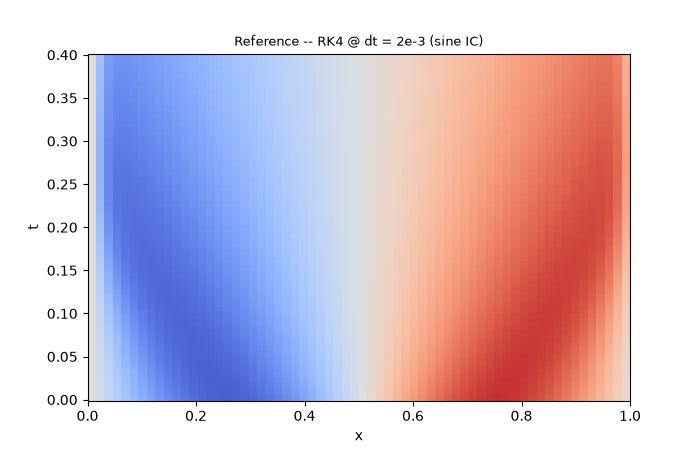

In [5]:
t_ref, U_ref, _, _ = runTrajectory('RK4', 2e-3, T, problem.rhs, makeSine)
print(f"reference: RK4 @ dt=2e-3, {len(t_ref) - 1} steps; "
      f"u in [{U_ref.min():.3f}, {U_ref.max():.3f}]")

plt.figure()
spacetime(plt.gca(), t_ref, U_ref, 'Reference -- RK4 @ dt = 2e-3 (sine IC)')
plt.show()

## 5. Explicit family

Four registered explicit schemes: **Forward Euler** run *past* the CFL wall
(`dt = 0.02`, to show what the wall is), then **SSP RK3**, **TVD RK3**, and
**RK4** at the stable `dt = 5e-3`.

The Forward Euler panel uses the **Gaussian** IC, the other three the sine:
a single-mode sine contains no high Fourier content for the unstable
amplifier `1 − dt·4ν/h² ≈ −2.3` to act on, so the same past-wall run on the
sine IC stays bounded (checked below) and would *not* show the wall. The
Gaussian's smooth flank is broadband — the generic case — and there the wall
bites within a few shock times.


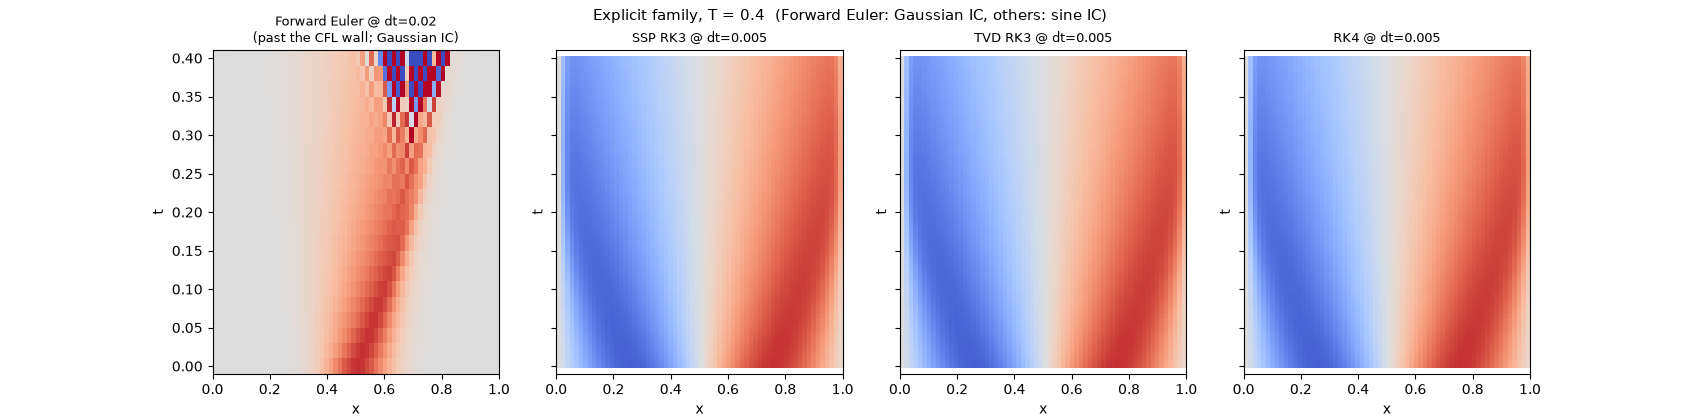

Forward Euler @ dt=0.02 (past the CFL wall; Gaussian IC) max|u| = 2.037e+01
SSP RK3 @ dt=0.005                           max|u| = 1.000e+00
TVD RK3 @ dt=0.005                           max|u| = 1.000e+00
RK4 @ dt=0.005                               max|u| = 1.000e+00


Forward Euler @ dt=0.02, sine IC, T=0.5: max|u| = 1.000e+00 (bounded)


In [6]:
DT_EXPL = 5e-3
explicitRuns = {
    'Forward Euler @ dt=0.02\n(past the CFL wall; Gaussian IC)': runTrajectory('Forward Euler', 0.02, T, problem.rhs, makeGauss),
    f'SSP RK3 @ dt={DT_EXPL:g}': runTrajectory('SSP RK3', DT_EXPL, T, problem.rhs, makeSine),
    f'TVD RK3 @ dt={DT_EXPL:g}': runTrajectory('TVD RK3', DT_EXPL, T, problem.rhs, makeSine),
    f'RK4 @ dt={DT_EXPL:g}': runTrajectory('RK4', DT_EXPL, T, problem.rhs, makeSine),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, explicitRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Explicit family, T = {T}  (Forward Euler: Gaussian IC, others: sine IC)', fontsize=11)
plt.show()

for title, (times, U, *_rest) in explicitRuns.items():
    print(f"{title.replace(chr(10), ' '):44s} max|u| = {np.abs(U).max():.3e}")

# The IC-dependence of the wall, made quantitative: the *same* past-wall
# Forward Euler run on the single-mode sine IC.
t_fe_sine, U_fe_sine, _, _ = runTrajectory('Forward Euler', 0.02, 0.5, problem.rhs, makeSine)
print(f"Forward Euler @ dt=0.02, sine IC, T=0.5: max|u| = {np.abs(U_fe_sine).max():.3e} (bounded)")

**Reading the panels:**

- The three stable schemes all show the shock forming at `t ≈ 0.16` and
  steepening — the diagonal feature marching right, where the faster
  (`u > 0`) characteristics overtake the slower ones. The fine wiggles riding
  the shock front are **Gibbs-like ringing from the central convective flux**:
  the semi-discretization is not monotone, so no explicit RK method removes
  them. They are *spatial*, not temporal, artifacts — which is exactly what
  the L-stable implicit schemes will damp.
- **Forward Euler @ dt = 0.02** (Gaussian IC) amplifies the stiffest mode by
  `|1 − dt·4ν/h²| ≈ 2.3` per step. The convective term seeds the high modes
  as the flank steepens; the growth stays invisible through `t ≈ 0.25`, then
  `max|u|` crosses 1 at `t ≈ 0.30` and the trajectory is running away —
  `~2e1` at `T = 0.4`, `~3e27` by `t = 0.5`. This is the parabolic CFL wall
  made visible: past it, an explicit method is simply not defined for this
  PDE at this resolution. (On the single-mode sine IC the same run stays
  bounded — see the print above — because there is no high-mode content to
  amplify; the wall's onset is set by the IC's spectral content.)


## 6. Implicit family

Backward Euler (order 1, L-stable), TR-BDF2 (order 2, L-stable),
ESDIRK4(3)6L[2]SA (order 4, L[2]-stable), BDF2 (order 2, A-stable,
`StepHistory` threaded), and **Radau IIA s=2** (order 3, L-stable — the
**coupled** block member: its two stage equations reference each other's
still-unknown stages, so they are solved *together* as one 2×N JFNK system
with the exact forward-mode Jacobian–vector product, instead of the DIRK
family's sequential stage solves) — every implicit stage closed by the
default **JFNK** solver, all at **`dt = 0.02`, 3.3× the explicit wall**.


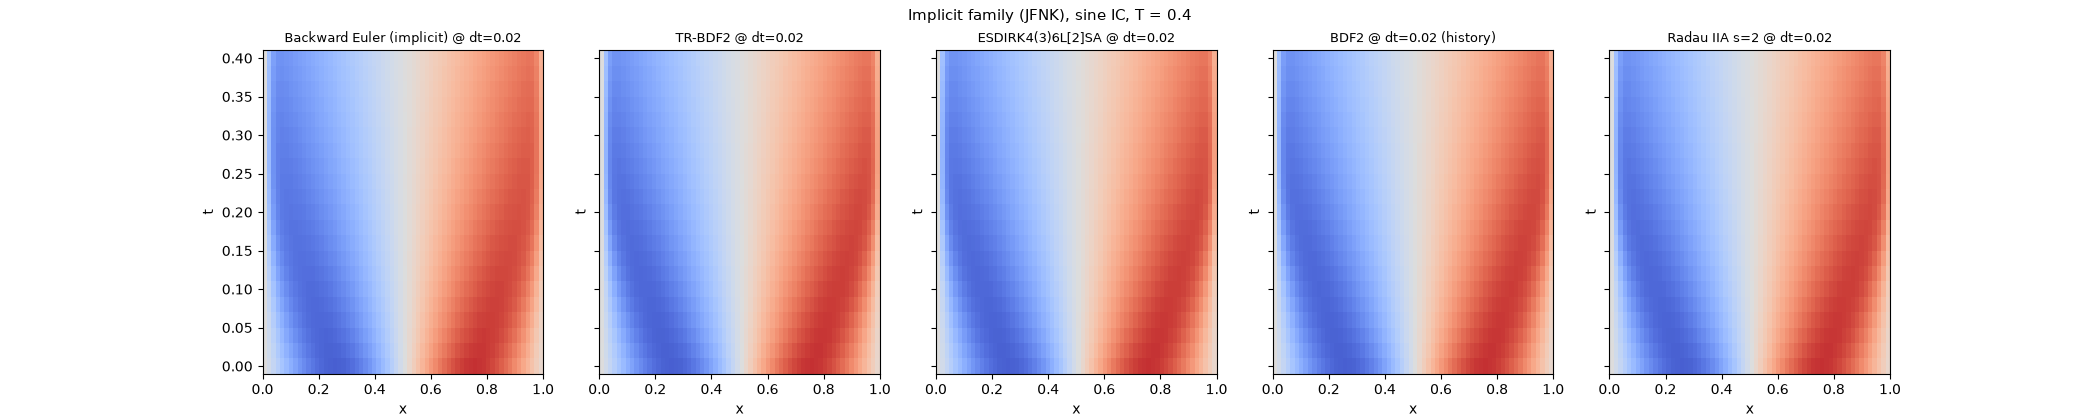

scheme                         steps   JFNK rhs evals  GMRES iters
Backward Euler (implicit)         20              110          413
TR-BDF2                           20              200          375
ESDIRK4(3)6L[2]SA                 20              500          869
BDF2                              20              104          289
Radau IIA s=2                     20              208          674


In [7]:
DT_STIFF = 0.02
implicitRuns = {
    f'Backward Euler (implicit) @ dt={DT_STIFF:g}': runTrajectory('Backward Euler (implicit)', DT_STIFF, T, problem.rhs, makeSine),
    f'TR-BDF2 @ dt={DT_STIFF:g}': runTrajectory('TR-BDF2', DT_STIFF, T, problem.rhs, makeSine),
    f'ESDIRK4(3)6L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ESDIRK4(3)6L[2]SA', DT_STIFF, T, problem.rhs, makeSine),
    f'BDF2 @ dt={DT_STIFF:g} (history)': runTrajectory('BDF2', DT_STIFF, T, problem.rhs, makeSine, history=True),
    f'Radau IIA s=2 @ dt={DT_STIFF:g}': runTrajectory('Radau IIA s=2', DT_STIFF, T, problem.rhs, makeSine),
}

fig, axes = plt.subplots(1, 5, figsize=(21, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, implicitRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Implicit family (JFNK), sine IC, T = {T}', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'JFNK rhs evals':>16s} {'GMRES iters':>12s}")
for title, (times, U, r, g) in implicitRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:16d} {g:12d}")


**Reading the panels:** same shock, same `T`, in 20 steps instead of 80 —
and stable where the explicit wall forbids it. The L-stable members (Backward
Euler, TR-BDF2, ESDIRK4, **Radau IIA s=2**) damped the central-flux ringing
almost completely; **BDF2** (A-stable, *not* L-stable) keeps a visible
high-frequency component on the shock — its stability region contains the
negative real axis but does not *damp* it. Backward Euler's extra smearing of
the shock profile is the visible price of its order-1 accuracy. Radau IIA s=2
(the coupled block member) reads like its L-stable cousins: at
`dt = 0.02` the stiffest mode's amplification is `|R(dt·4ν/h²)| ≈ 0.02`, so
the ringing is gone in the first step, and its order-3 profile sits between
Backward Euler's smear and ESDIRK4's near-reference sharpness. Its block
solve is a little more expensive per step than the DIRK family's sequential
stage solves (one coupled 2×N Newton–Krylov solve plus the null-stage
companion evaluation), visible in the RHS-evaluation column below.


## 7. IMEX family: the additive split

Viscous Burgers is the textbook case for an additive method: put the **stiff**
part implicit and the **smooth** part explicit. Here that is
`implicit = L` (diffusion) and `explicit = N` (convective) — the same two
pieces the `SemilinearRHS` declares. We build the additive object from the
problem's own parts with the public `resolve` entry point (no
re-discretization):

```python
parts = resolve(problem.rhs, scheme_name='IMEX demo')
imex_rhs = IMEXRHS(explicit=parts.nonlinear, implicit=parts.linear)
```

`IMEXRHS` is a Phase 14 constructor (returns a typed `RHS` with
`provides = {"explicit", "implicit"}` and a summing `__call__`), and
`check_contracts` verifies `explicit + implicit == f` on it. **IMEX Euler**
(order 1), **ARK3(2)4L[2]SA** (order 3) and **ARK4(3)6L[2]SA** (order 4) read
the split by capability; a scheme handed the *combined* `SemilinearRHS`
instead runs its pure-implicit limit (the Phase 5 compatibility rule — no
split is silently discarded). The explicit half here is only the convective
term (eigenvalues imaginary, `|λ| ≲ max|u|/h = 64`), so `dt = 0.02` is
comfortably inside the ARK pair's explicit-stage stability region while the
diffusion — the actual stiff term — is treated implicitly.

**SBDF2** (order 2), **SBDF3** (order 3) and **CNAB2** (order 2) are the
IMEX multistep members: a BDF2 / BDF3 / trapezoidal *implicit* backbone for
the stiff part, with the smooth part extrapolated explicitly to the endpoint
(SBDF2: `2Nⁿ − Nⁿ⁻¹`, SBDF3: `3Nⁿ − 3Nⁿ⁻¹ + Nⁿ⁻²`, CNAB2: the AB2 increment
`3Nⁿ/2 − Nⁿ⁻¹/2`). In SBDF2/3 the BDF derivative weight `β`
(BDF2: 3/2, BDF3: 12/5) scales the *whole* endpoint derivative — implicit
and extrapolated explicit part alike — and dropping it from the
extrapolation would amplify that part by `1/β` and make the combined method
first order (a regression the test suite pins); CNAB2 carries the same
consistency in the trapezoidal rule's own `dt/2` weights. Handed a plain
callable instead of a split, each member runs its pure-implicit limit —
BDF2 / BDF3 / the registered trapezoidal scheme — so the standard integrator
call convention stays valid. Their *effective explicit method* (the
pure-explicit limit, the full scheme with `L ≡ 0`) is a 2- or 3-step
explicit multistep method whose stability lobe barely reaches along the
imaginary axis — on this grid it stays bounded at `64·dt = 0.512` and runs
to NaN at `64·dt = 0.64` — so, unlike the ARK pair, the multistep members
step at **`dt = 0.008` (SBDF2, CNAB2) and `dt = 0.004` (SBDF3)**, where the
convective `|z| ≤ 64·dt` stays inside the lobe. Like BDF2 in §6 they need
`history=True` (state snapshots of the previous `p` steps).

imex_rhs provides: ['explicit', 'implicit']
check_contracts (explicit + implicit == f): OK


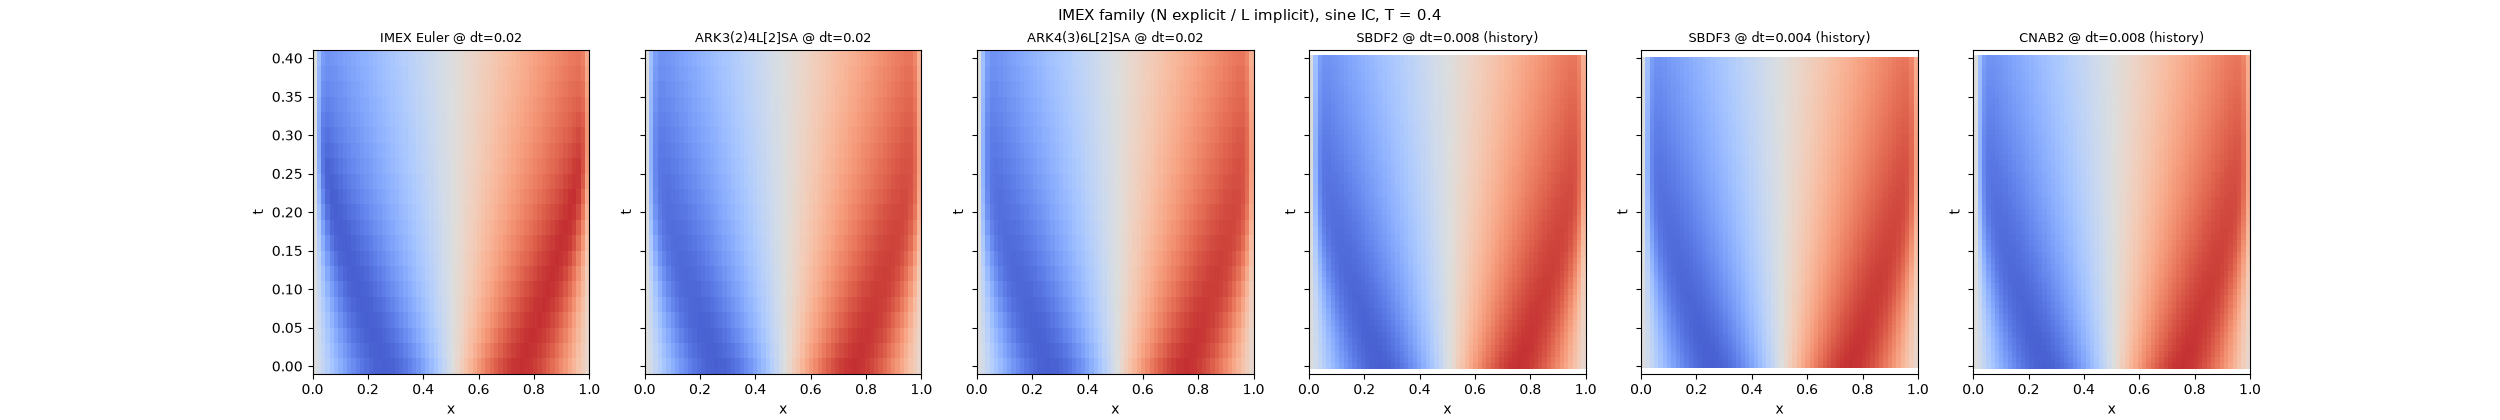

scheme                         steps   JFNK rhs evals  GMRES iters
IMEX Euler                        20               80          265
ARK3(2)4L[2]SA                    20              240          553
ARK4(3)6L[2]SA                    20              400          741
SBDF2                             50              343          370
SBDF3                            100              784          507
CNAB2                             50              343          330


In [8]:
parts = resolve(problem.rhs, scheme_name='IMEX demo')
imex_rhs = IMEXRHS(explicit=parts.nonlinear, implicit=parts.linear)
print('imex_rhs provides:', sorted(imex_rhs.provides))
check_contracts(imex_rhs, init, dt=DT_STIFF)
print('check_contracts (explicit + implicit == f): OK')

imexRuns = {
    f'IMEX Euler @ dt={DT_STIFF:g}': runTrajectory('IMEX Euler', DT_STIFF, T, imex_rhs, makeSine),
    f'ARK3(2)4L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ARK3(2)4L[2]SA', DT_STIFF, T, imex_rhs, makeSine),
    f'ARK4(3)6L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ARK4(3)6L[2]SA', DT_STIFF, T, imex_rhs, makeSine),
    f'SBDF2 @ dt=0.008 (history)': runTrajectory('SBDF2', 0.008, T, imex_rhs, makeSine, history=True),
    f'SBDF3 @ dt=0.004 (history)': runTrajectory('SBDF3', 0.004, T, imex_rhs, makeSine, history=True),
    f'CNAB2 @ dt=0.008 (history)': runTrajectory('CNAB2', 0.008, T, imex_rhs, makeSine, history=True),
}

fig, axes = plt.subplots(1, 6, figsize=(25, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, imexRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'IMEX family (N explicit / L implicit), sine IC, T = {T}', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'JFNK rhs evals':>16s} {'GMRES iters':>12s}")
for title, (times, U, r, g) in imexRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:16d} {g:12d}")

**Reading the panels:** the ARK pairs resolve the shock as well as their
order-3/4 standalone-implicit cousins do, with the convective term costing
only cheap explicit evaluations. IMEX Euler is order 1 like Backward Euler —
its shock is smeared the same way — and carries a small overshoot at the shock
foot (`max|u|` slightly above 1): the explicit convective half adds a touch of
the ringing the fully-implicit runs do not have.

**SBDF2 / SBDF3 / CNAB2** (the multistep members, at their smaller `dt`)
read as the family's stiffer-accuracy trade: their implicit backbones
(BDF2, BDF3, trapezoidal) are A-stable but *not* L-stable, so none kills the
central-flux ringing as completely as the L-stable ARK members do — a faint
high-frequency trace stays on the shock, like BDF2's in §6 — while the
endpoint extrapolation carries the convective term at order 2/3, so their
shock profiles sit between IMEX Euler's smear and ARK3's. The cost column
shows the price of the multistep structure: one implicit solve plus 2
(SBDF2, CNAB2) or 3 (SBDF3) explicit-part evaluations and one endpoint
evaluation per step, at 40% or 20% of the ARK pair's `dt`.

## 8. Rosenbrock-W family: one linear solve per stage

The newest stiff family (roadmap **Phase 7**): the third-order Rosenbrock-W
method **`ROS3P`** (Lang & Verwer, *BIT* 41(4), 2001). A Rosenbrock method
advances a stiff ODE `u' = f(t, u)` with a single *linear* solve per stage —
**no Newton iteration, no nonlinear loop**. Each stage `K_i` is a Krylov solve
against a *frozen* operator `W ≈ ∂f/∂u` built once per step, and the final
value is the explicit combination `u_{n+1} = u_n + (2K_1 + K_3)τ/3`. The
difference from the JFNK families (§6) and the additive ARK pairs (§7): those
re-linearize at every nonlinear solve, while ROS3P freezes the Jacobian once
and pays one linear solve per stage.

The library's `w=` selector picks how the frozen operator is built:

- **`w='jvp'`** (default) — the exact Jacobian–vector product `W = ∂f/∂u` via
  forward-mode autodiff. **Order 3.**
- **`w='fd'`** — a finite-difference Jacobian–vector product. **Order 3**, no
  autodiff (the portable choice).
- **`w='linear'`** — the structured-RHS *linear* operator only. Order 3 for a
  genuinely linear right-hand side, but **order 1 on this semilinear PDE** (it
  omits the convective Jacobian) — the cheap option when the nonlinearity is
  weak.

`ROS3P` is **A-stable but not L-stable** (`R(∞) = 1 − √3 ≈ −0.732`), so the
stiffest modes are damped to ~73% per step — less damping than the L-stable
ESDIRK / TR-BDF2 members, but no nonlinear iteration to pay for it. The
non-autonomous `∂f/∂t` term is carried by a one-sided finite difference (the
RHS here is autonomous, so it costs nothing in practice). Cost: **3 GMRES
solves per step**, no Newton.

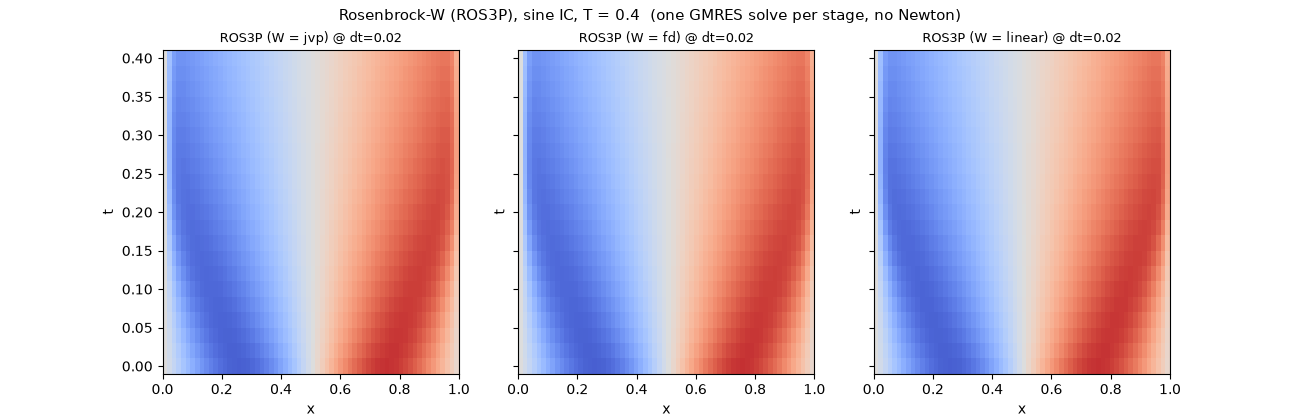

scheme                         steps  RHS evals  GMRES iters
ROS3P (W = jvp)                   20        706          586
ROS3P (W = fd)                    20        715          595
ROS3P (W = linear)                20         60          783


In [9]:
rwRuns = {
    f'ROS3P (W = jvp) @ dt={DT_STIFF:g}': runTrajectory('ROS3P', DT_STIFF, T, problem.rhs, makeSine, w='jvp'),
    f'ROS3P (W = fd) @ dt={DT_STIFF:g}': runTrajectory('ROS3P', DT_STIFF, T, problem.rhs, makeSine, w='fd'),
    f'ROS3P (W = linear) @ dt={DT_STIFF:g}': runTrajectory('ROS3P', DT_STIFF, T, problem.rhs, makeSine, w='linear'),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, rwRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Rosenbrock-W (ROS3P), sine IC, T = {T}  (one GMRES solve per stage, no Newton)', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'RHS evals':>10s} {'GMRES iters':>12s}")
for title, (times, U, r, g) in rwRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:10d} {g:12d}")

**Reading the panels:** the two frozen-Jacobian variants (`jvp`, `fd`) resolve
the shock cleanly at order 3 — the frozen Jacobian is a good linearization of
the whole (stiff + convective) operator, and one GMRES solve per stage closes
each stage with no Newton loop. `W = linear` is visibly more smeared: it uses
only the diffusion operator as the frozen linearization and drops the
convective Jacobian, so on this *semilinear* PDE it is order 1 (it is order 3
for a genuinely linear right-hand side). That is the trade the `w=` selector
exposes: `linear` is the cheap operator for weakly-nonlinear problems, `jvp`/
`fd` are the full-accuracy options. The cost (below and in the §11 table) is
3 GMRES solves per step with **no nonlinear iteration** — compare the JFNK
families in §6, which re-linearize inside a Newton loop at every stage solve.
The measured order-3 convergence of `ROS3P (W = jvp)` on the Gaussian IC is in
the §10 study.

## 9. Exponential family: ETD2RK and EXPRB32

The last stiff family for a semilinear PDE (roadmap **Phase 7**) now has two
members on this problem. First, **`ETD2RK`** (2-stage, order 2, L-stable for
the linear part; Sarumi, arXiv:2601.06849, `phi` per Caliari & Ostermann 2009)
— the method that consumes the `linear`/`nonlinear` split most directly. Where
the JFNK families (§6) close every implicit stage and Rosenbrock-W (§8)
freezes a Jacobian and solves a linear system per stage, an exponential
integrator carries the stiff linear part `L` **exactly** through the matrix
functions `exp(hL)` and `phi_1(hL)` / `phi_2(hL)` — applied **matrix-free**
as `phi_k(hL) v` via a Krylov (Arnoldi) build on `L` (no dense matrix, no
eigen-decomposition) — and only *quadratures* the mild nonlinear part `N`
(two evaluations per step, `N(t_n, y_n)` and `N(t_n + h, w)`):

$$
y_{n+1} = e^{hL} y_n + h\,\phi_1(hL)\,N(t_n, y_n)
         + h\,\phi_2(hL)\,\big(N(t_n + h, w) - N(t_n, y_n)\big), \qquad
w = e^{hL} y_n + h\,\phi_1(hL)\,N(t_n, y_n)
$$

The linear part has **no truncation error** (it is integrated exactly), so the
order comes from the quadrature of `N` — order 2. The cost is the three
matrix-function actions per step: each is a fresh Krylov build on `L` (the
three right-hand-side vectors differ), so a step costs two `N` evaluations
plus three `L`-matvec Krylov builds (each up to `m = 30` Arnoldi steps).
Because `L` is constant, the gradient re-attaches each action with its
transpose as the adjoint — exact up to the Krylov tolerance (the cleanest
gradient story in the Phase 7 set, in contrast to ROS3P's frozen-`W`, which
drops a `dW/dy` Hessian and is O(dt)). The measured order-2 convergence is in
the §10 study; the cost is in the §11 table.

The family's second member, **`EXPRB32`** (Hochbrueck, Ostermann & Schweitzer,
*SIAM J. Numer. Anal.* 47(1), 2009, §2.3 with the §6.5 frozen-`Jn`
reformulation), does **not** need the split: it freezes the *full* Jacobian
`Jn = ∂f/∂u(t_n, y_n)` (forward-mode AD by default; `f_t='none'` drops the
finite-difference `∂f/∂t` term) and applies every `phi_k(hJn)` its two stages
need matrix-free, through the same Krylov (Arnoldi) machinery as ETD2RK's
`phi_k(hL)` builds. A step costs **four full-`f` evaluations** at the default
`f_t='fd'` (three with `f_t='none'`) plus up to three `Jn`-matvec Krylov
builds — two in the main stage, one more for the **embedded (3, 2) estimate**
(skipped when its driving term vanishes). It is **L-stable**, and — unlike
ETD2RK's cheap `ν·u_xx` stencil matvecs — every EXPRB32 Krylov matvec is a
*full Jacobian–vector product*, the same cost class as a full `f` evaluation,
so the §11 work-unit metric is fair for it. That is the method that carries
the exponential family's cost gate: its order-3 convergence is in §10, and
the cost and the gate verdict are in §11.


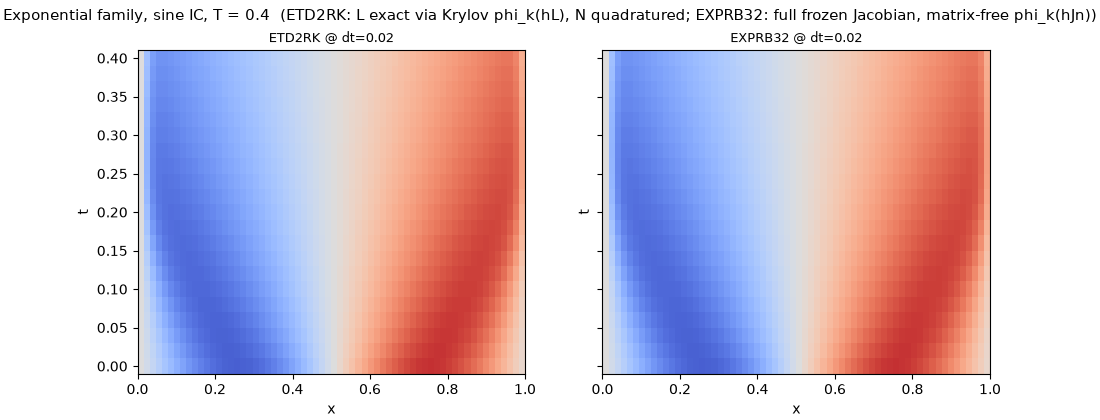

scheme                         steps  RHS evals  Krylov iters
ETD2RK                            20         40          1742
EXPRB32                           20         80          1200


In [10]:
expRuns = {
    f'ETD2RK @ dt={DT_STIFF:g}': runTrajectory('ETD2RK', DT_STIFF, T, problem.rhs, makeSine),
    f'EXPRB32 @ dt={DT_STIFF:g}': runTrajectory('EXPRB32', DT_STIFF, T, problem.rhs, makeSine),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (title, (times, U, *_rest)) in zip(axes, expRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Exponential family, sine IC, T = {T}  '
             f'(ETD2RK: L exact via Krylov phi_k(hL), N quadratured; '
             f'EXPRB32: full frozen Jacobian, matrix-free phi_k(hJn))', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'RHS evals':>10s} {'Krylov iters':>13s}")
for title, (times, U, r, g) in expRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:10d} {g:13d}")


## 10. Convergence: measured orders on the PDE

Endpoint relative `L2` error at `t = T = 0.4` against the fine-`dt` RK4
reference, **Gaussian IC** (smoother — the error is less dominated by the
shock), on `dt` values that divide `T` exactly (10/20/40 steps — a mismatched
endpoint would contaminate the coarsest point). The measured orders are the
slopes between consecutive pairs. `ROS3P (W = jvp)` (order 3), `EXPRB32`
(order 3) and `ETD2RK` (order 2) each run a finer `dt` ladder
(5/10/20/40/80 steps) so their lines are well resolved. The IMEX multistep
members (SBDF2/3, CNAB2) run two-`dt` ladders at their explicit-half-limited
step sizes — the convective spectrum, not the diffusion, caps their `dt`.

scheme                              relative L2 error @ T   measured orders


RK4                        ['1.81e-06', '1.05e-07', '3.86e-09']   ['4.11', '4.76']


Backward Euler (implicit)  ['8.86e-02', '4.97e-02', '2.66e-02']   ['0.83', '0.90']


TR-BDF2                    ['3.35e-03', '8.02e-04', '1.97e-04']   ['2.06', '2.02']


ESDIRK3(2)4L[2]SA          ['1.06e-03', '1.54e-04', '2.11e-05']   ['2.78', '2.87']


...

SBDF3 (history)            ['4.12e-05', '5.07e-06']   ['3.02']


CNAB2 (history)            ['1.31e-03', '3.25e-04']   ['2.01']


ROS3P (W = jvp)            ['2.40e-02', '3.69e-03', '5.64e-04', '8.01e-05', '1.07e-05']   ['2.70', '2.71', '2.82', '2.90']


ETD2RK                     ['2.34e-01', '2.15e-02', '5.09e-03', '1.24e-03', '3.06e-04']   ['3.44', '2.08', '2.04', '2.02']


EXPRB32                    ['2.72e-03', '3.50e-04', '4.41e-05', '5.55e-06', '6.97e-07']   ['2.96', '2.99', '2.99', '2.99']


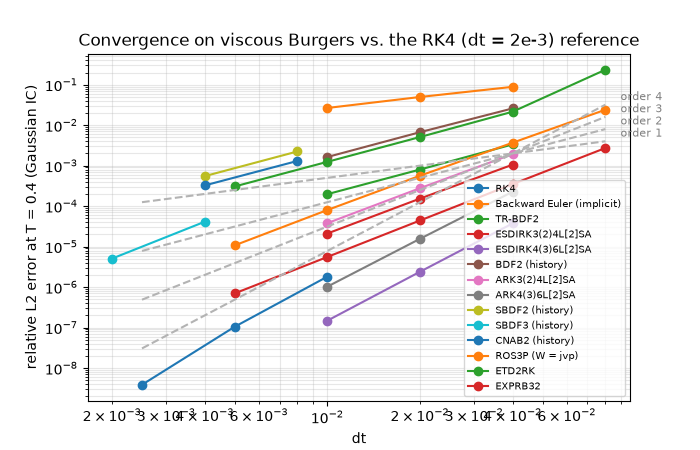

In [11]:
t_gref, Ug_ref, _, _ = runTrajectory('RK4', 2e-3, T, problem.rhs, makeGauss)

# (label, scheme, dts, f, history, scheme_kwargs) -- the last field carries a
# scheme's own per-step parameter (ROS3P's w=).
convRuns = [
    ('RK4',                     'RK4',                     [0.01, 0.005, 0.0025], problem.rhs, False, {}),
    ('Backward Euler (implicit)', 'Backward Euler (implicit)', [0.04, 0.02, 0.01], problem.rhs, False, {}),
    ('TR-BDF2',                 'TR-BDF2',                 [0.04, 0.02, 0.01],    problem.rhs, False, {}),
    ('ESDIRK3(2)4L[2]SA',       'ESDIRK3(2)4L[2]SA',       [0.04, 0.02, 0.01],    problem.rhs, False, {}),
    ('ESDIRK4(3)6L[2]SA',       'ESDIRK4(3)6L[2]SA',       [0.04, 0.02, 0.01],    problem.rhs, False, {}),
    ('BDF2 (history)',          'BDF2',                    [0.04, 0.02, 0.01],    problem.rhs, True,  {}),
    ('ARK3(2)4L[2]SA',          'ARK3(2)4L[2]SA',          [0.04, 0.02, 0.01],    imex_rhs,    False, {}),
    ('ARK4(3)6L[2]SA',          'ARK4(3)6L[2]SA',          [0.04, 0.02, 0.01],    imex_rhs,    False, {}),
    ('SBDF2 (history)',         'SBDF2',                   [0.008, 0.004],        imex_rhs,    True,  {}),
    ('SBDF3 (history)',         'SBDF3',                   [0.004, 0.002],        imex_rhs,    True,  {}),
    ('CNAB2 (history)',         'CNAB2',                   [0.008, 0.004],        imex_rhs,    True,  {}),
    ('ROS3P (W = jvp)',         'ROS3P',                   [0.08, 0.04, 0.02, 0.01, 0.005], problem.rhs, False, {'w': 'jvp'}),
    ('ETD2RK',                  'ETD2RK',                  [0.08, 0.04, 0.02, 0.01, 0.005], problem.rhs, False, {}),
    ('EXPRB32',                 'EXPRB32',                 [0.08, 0.04, 0.02, 0.01, 0.005], problem.rhs, False, {}),
]

print(f"{'scheme':26s} {'relative L2 error @ T':>30s}   measured orders")
convData = {}
for label, name, dts, f, hist, kw in convRuns:
    errs = []
    for dt in dts:
        times, U, _, _ = runTrajectory(name, dt, T, f, makeGauss, history=hist, **kw)
        errs.append(float(np.linalg.norm(U[-1] - Ug_ref[-1]) / np.linalg.norm(Ug_ref[-1])))
    orders = [math.log(errs[i] / errs[i + 1]) / math.log(dts[i] / dts[i + 1])
              for i in range(len(errs) - 1)]
    convData[label] = (dts, errs)
    print(f"{label:26s} {['%.2e' % e for e in errs]}   {['%.2f' % o for o in orders]}")

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, (dts, errs) in convData.items():
    ax.loglog(dts, errs, 'o-', label=name)
x0 = 0.04
for p in (1, 2, 3, 4):
    xs = np.array([x0 / 16, 2 * x0])
    ys = 2e-3 * (xs / x0) ** p
    ax.loglog(xs, ys, '--', c='0.7')
    ax.text(2 * x0 * 1.12, ys[1] * 1.3, f'order {p}', fontsize=8, c='0.5')
ax.set_xlabel('dt')
ax.set_ylabel('relative L2 error at T = 0.4 (Gaussian IC)')
ax.set_title('Convergence on viscous Burgers vs. the RK4 (dt = 2e-3) reference')
ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)
plt.show()

**Reading the plot:** the measured orders are the advertised ones on a
physical PDE — RK4 → ~4, ESDIRK4/ARK4 → ~4, TR-BDF2/BDF2 → ~2,
SBDF2/CNAB2 → ~2.0, SBDF3 → ~3.0, ARK3/ROS3P → ~2.9, EXPRB32 → ~2.99,
ETD2RK → ~2, Backward Euler → ~0.9.
Nothing here saturates: the reference is the *same* semi-discrete system (RK4
at `dt = 2e-3`, temporal error ~1e-7), so no spatial floor enters the
comparison — Backward Euler is simply still deep in its O(dt) regime, with
2.7% relative error at `dt = 0.01`. (BDF2's coarsest point carries a small
Dormand-Prince cold-start transient — the multistep starter,
`multistep.py` —; the slope from `dt ≤ 0.02` is its true order 2. The
SBDF2/3 and CNAB2 ladders start already past their cold start.)

Two order-3 methods, two error constants: `EXPRB32` sits ~13× below
`ROS3P (W = jvp)` on the same order-3 line (4.41e-05 vs 5.64e-04 at
`dt = 0.02`), and that smaller constant is exactly what lets it reach the §11
target error one step size earlier (`dt = 0.04` vs `dt = 0.02`) — the whole
cost gate in one number. (SBDF3's order-3 error is also small — 5.07e-06 at
`dt = 0.002` — but its step is limited by the explicit half, so the §11 cost
gate does not include it.)

For reference, here is what the Gaussian run looks like under one
representative scheme per family (the shock forms on the pulse's left flank):

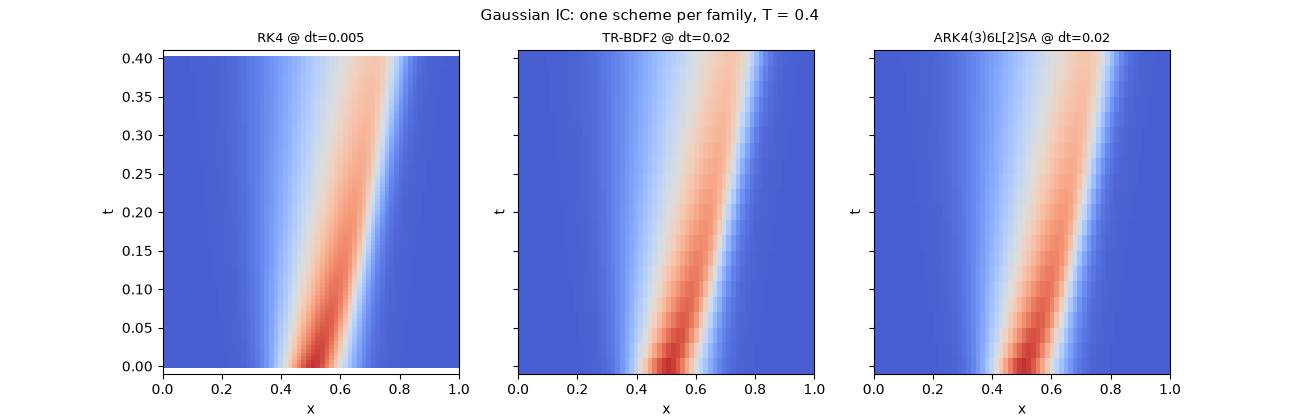

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
gaussRuns = {
    f'RK4 @ dt={DT_EXPL:g}': runTrajectory('RK4', DT_EXPL, T, problem.rhs, makeGauss),
    f'TR-BDF2 @ dt={DT_STIFF:g}': runTrajectory('TR-BDF2', DT_STIFF, T, problem.rhs, makeGauss),
    f'ARK4(3)6L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ARK4(3)6L[2]SA', DT_STIFF, T, imex_rhs, makeGauss),
}
for ax, (title, (times, U, *_)) in zip(axes, gaussRuns.items()):
    spacetime(ax, times, U, title, vmin=-0.05, vmax=1.05)
fig.suptitle(f'Gaussian IC: one scheme per family, T = {T}', fontsize=11)
plt.show()

## 11. Cost

Showcase runs (sine IC, `T = 0.4`). Steps = `T/dt`. For every family the
columns are the Phase 1 `SolveDiagnostics` summed over every stage solve of
the run: `RHS evals` counts full right-hand-side evaluations and `GMRES iters`
counts Krylov iterations. The **`total`** column is the work-unit budget the
cost gate compares — the JFNK invariant `total = RHS evals + GMRES iters`
(each Newton residual / trial is a full `f`, each GMRES iteration is one
operator application). Three accounting notes, called out below the table.
For `ROS3P` with `W = jvp`/`fd` every GMRES matvec *is* a full Jacobian sweep
(or FD evaluation), so those matvecs already sit in `RHS evals` and
`total = RHS evals` (adding the `GMRES iters` column would double-count them).
For `ETD2RK` the `GMRES iters` column is the **`L`-matvec (Krylov) count** —
the three per-step `phi_k(hL)` builds, each up to `m = 30` Arnoldi steps — so
`total = RHS evals + L-matvec iters`; because an `L`-matvec is a cheap
`ν·u_xx` stencil, this total *overstates* ETD2RK's FLOP cost. For
**`EXPRB32`** the Krylov matvecs are **full Jacobian–vector products** — the
same cost class as a full `f` evaluation — so its `total = RHS evals +
JVP-matvec iters` is a *fair* FLOP proxy, with no double count (each JVP is
counted once, in `GMRES iters`).

| family         | scheme                | dt    | steps | RHS evals | GMRES iters | total |
|----------------|-----------------------|-------|-------|-----------|-------------|-------|
| explicit       | Forward Euler (stable)| 0.005 | 80    | 80        | —           | 80    |
| explicit       | SSP RK3 / TVD RK3     | 0.005 | 80    | 240       | —           | 240   |
| explicit       | RK4                   | 0.005 | 80    | 320       | —           | 320   |
| implicit       | Backward Euler        | 0.02  | 20    | 110       | 413         | 523   |
| implicit       | TR-BDF2               | 0.02  | 20    | 200       | 375         | 575   |
| implicit       | ESDIRK3(2)4L[2]SA     | 0.02  | 20    | 300       | 688         | 988   |
| implicit       | ESDIRK4(3)6L[2]SA     | 0.02  | 20    | 500       | 869         | 1369  |
| implicit       | BDF2                  | 0.02  | 20    | 104       | 289         | 393   |
| IMEX           | IMEX Euler            | 0.02  | 20    | 80        | 265         | 345   |
| IMEX           | ARK3(2)4L[2]SA        | 0.02  | 20    | 240       | 553         | 793   |
| IMEX           | ARK4(3)6L[2]SA        | 0.02  | 20    | 400       | 741         | 1141  |
| IMEX multistep | SBDF2 (history)       | 0.008 | 50    | 343       | 370         | 713   |
| IMEX multistep | SBDF3 (history)       | 0.004 | 100   | 784       | 507         | 1291  |
| IMEX multistep | CNAB2 (history)       | 0.008 | 50    | 343       | 330         | 673   |
| Rosenbrock-W   | ROS3P (W = jvp)       | 0.02  | 20    | 706       | 586         | 706   |
| Rosenbrock-W   | ROS3P (W = fd)        | 0.02  | 20    | 715       | 595         | 715   |
| Rosenbrock-W   | ROS3P (W = linear)    | 0.02  | 20    | 60        | 783         | 843   |
| exponential    | ETD2RK                | 0.02  | 20    | 40        | 1742        | 1782  |
| exponential    | EXPRB32               | 0.02  | 20    | 80        | 1200        | 1280  |

The structural reading: to reach `T = 0.4` the stiff families need **20 steps**
where explicit needs **80**. **At this shared `dt = 0.02`, `ROS3P (W = jvp)`
is the cheapest order-3 method on total work-units (706) — below the additive
`ARK3` (793) and the fully-implicit `ESDIRK3` (988) — and it also beats
`ESDIRK3` on GMRES iterations (586 < 688)**; `EXPRB32`'s 1280 here is the
per-step price of freezing the full Jacobian, and it is *not* what the cost
gate compares (the fixed-error table below). Two honest caveats. First, the
additive `ARK3` split's 553 GMRES iterations are *cheap linear-operator*
applications (the IMEX split hands the stiff diffusion to the `linear` part),
whereas `ROS3P`'s 586 iterations are full Jacobian sweeps — so `ARK3` is
cheaper *per iteration in FLOPs* even though its work-unit count is higher.
Second, `ROS3P (W = linear)` is the cheapest in full-`f` evaluations (60) but
is only order 1 on this semilinear PDE (it drops the convective Jacobian) and
pays for it in the most GMRES iterations here (783); it is the cheap
low-order option, not a stand-in for the full Jacobian. The IMEX rows sit
below their fully-implicit order cousins (4th-order ARK4: 400 vs 4th-order
ESDIRK4: 500 RHS evals) because the convective half costs plain evaluations
and only the diffusion half goes through the implicit solve.

The three IMEX multistep rows (SBDF2/3, CNAB2) run at their explicit-half
step sizes, so they compare at 2.5–5× the step count: their per-step price
is the lowest in the table (GMRES per step: SBDF3 ≈ 5.1, CNAB2 ≈ 6.6,
SBDF2 ≈ 7.4 — the implicit system is the fixed linear diffusion operator,
not the full nonlinear `f`), but the small `dt` multiplies it out: SBDF2's
total (713) sits above fully-implicit BDF2's order-2 row (393 at `dt = 0.02`)
and SBDF3 (1291) is the most expensive order-3 row here. The split pays off
when the nonlinear part is expensive relative to the linear solve (or the
diffusion-only system is much better conditioned); at this `n = 64` size the
RHS is cheap, so the fully-implicit rows still win on raw cost. The
multistep rows earn their place in the take-away table's regime: order 2/3
at a step size the convective spectrum allows, with one cheap solve and a
few explicit evaluations per step.

**ETD2RK** (exponential, order 2): its 40 `N` evaluations are few (two per
step), but its three per-step `L`-matvec Krylov builds each run to the full
`m = 30` — the benchmark's `||h·L|| ≈ 3.3` does not drive the Arnoldi residual
below `1e-10` early — so its work-unit total (1782) sits **above** the
order-2 bars (BDF2 393, TR-BDF2 575). Each `L`-matvec is a cheap `ν·u_xx`
stencil, not a full JFNK `N + L` evaluation, so the work-unit metric
**overstates** ETD2RK's true FLOP cost — the family's cost case therefore
rests on its order-3 member.

**EXPRB32** (exponential, order 3): 80 full-`f` evaluations (four per step at
the default `f_t='fd'`) plus 1200 Krylov iterations, each a full
Jacobian–vector product — a fair work unit — for a total of 1280, the most
expensive stiff row at this `dt`. But the gate does not compare per-step
prices at one `dt`:

**The order-3 cost gate at fixed error.** The gate is "beat the same-order
cost to a fixed error": each order-3 method may take the *largest* `dt` that
reaches the target (a small error constant earns a larger step), and the work
at that `dt` is compared. Target: relative `L2` error `≤ 1e-3` at `T = 0.4`,
sine IC:

| scheme            | dt    | steps | rel L2 err | RHS evals | Krylov iters | total |
|-------------------|-------|-------|------------|-----------|--------------|-------|
| EXPRB32 (jvp)     | 0.04  | 10    | 1.222e-04  | 40        | 600          | 640   |
| ROS3P (W = jvp)   | 0.02  | 20    | 2.038e-04  | 706       | — (in RHS)   | 706   |
| ESDIRK3(2)4L[2]SA | 0.04  | 10    | 5.211e-04  | 164       | 551          | 715   |
| ARK3(2)4L[2]SA    | 0.02  | 20    | 2.628e-04  | 240       | 553          | 793   |

**Gate: met.** EXPRB32 is the cheapest order-3 method at the fixed error —
640 work-units in 10 steps — and it also lands the smallest error of the four
(1.222e-04). Its error constant on the order-3 line is ~13× below ROS3P's
(§10), which is exactly what lets it take `dt = 0.04` where ROS3P only
reaches the target at `dt = 0.02`. Two honest caveats: the 9% margin over
ROS3P is a *work-unit* win (a full JVP and a full `f` count equally in this
metric), not a FLOP blowout; and at the same `dt = 0.02` EXPRB32 is the most
expensive stiff method in this table (1280 vs 706 / 793 / 988) — the gate
rewards the largest accurate step, not the per-step price.

## 12. Phase 7 is complete

All three of Phase 7's methods are now on this problem. **Rosenbrock-W**
landed as §8 (`ROS3P`: one linear solve per stage against a frozen Jacobian,
no Newton loop; order 3, the cheapest order-3 total at the shared
`dt = 0.02`). The **exponential** family landed as §9 with two members:
**`ETD2RK`** — the linear part `L` integrated exactly through matrix-free
`phi_k(hL)` Krylov builds, the nonlinear remainder quadratured (two
evaluations per step); order 2, L-stable for the linear part — and
**`EXPRB32`** — order-3 exponential Rosenbrock on the *full* frozen Jacobian
(no semilinear split required; the same `krylov_phi` machinery building on
`Jn` instead of `L`), L-stable, with a built-in (3, 2) error estimate.

The family's cost gate — "beat the same-order cost to a fixed error" — is
**met** (§11): at relative `L2` error `≤ 1e-3`, `T = 0.4`, sine IC, EXPRB32
reaches the target at `dt = 0.04` in **640** work-units, below `ROS3P`'s 706
(`dt = 0.02`), `ESDIRK3`'s 715 (`dt = 0.04`) and `ARK3`'s 793 (`dt = 0.02`) —
and with the smallest error of the four. Phase 7 is closed — and the roadmap
items it pointed to have since closed too: **Phase 6**'s coupled
block-implicit RK (Radau IIA s=2 is on this problem in §6; its symplectic
companion Gauss-Legendre 2 is in the library — NOTES §3.18), **Phase 11**'s
adaptive step control (NOTES §3.17), and **Phase 12**'s RKC/RKL
super-timestepping (NOTES §3.13) plus its IMEX multistep family —
**SBDF2/3** and **CNAB2**, on this problem in this very §7 (NOTES §3.19);
whatever remains open continues in `IMPLICIT_ROADMAP.md`.

## Take-aways

| regime | family to reach for | why (on this PDE) |
|--------|--------------------|-------------------|
| `dt ≤ ~1.2e-2`, accuracy-first | **Explicit** (RK4 / TVD RK3) | no solves; the central-flux ringing is spatial, so order buys resolution, not monotonicity |
| `dt > 1.2e-2`, accuracy-first | **Implicit** (ESDIRK4, TR-BDF2) / **Rosenbrock-W** (ROS3P) or **IMEX** (ARK3/4) | stiff diffusion handled without the explicit wall, order 2–4; the L-stable members also kill the ringing |
| `dt > 1.2e-2`, cheapest | **IMEX Euler / Backward Euler** | order 1 — the shock is smeared, but only one stage solve per step |
| split available, multistep accuracy, `dt` capped by the convective spectrum | **IMEX multistep** (SBDF2/3, CNAB2, §7) | BDF2/3/trapezoidal implicit backbone + explicit endpoint extrapolation, order 2/3; the explicit half's narrow stability lobe forces a smaller `dt` than the ARK pair, but the step is one cheap solve plus a few explicit evaluations |
| coupled tableau (off-diagonal `a_ij` ≠ 0), stiff | **Coupled block RK** (Radau IIA s=2, §6) | one 2×N JFNK block solve per step (exact-JVP matvec); L-stable, so it kills the ringing like the DIRK cousins; order 3; Gauss-Legendre 2 in the same family is the symplectic choice for oscillatory problems instead (NOTES §3.18) |
| frozen Jacobian, no Newton loop, semilinear | **Rosenbrock-W** (ROS3P, §8) | one linear solve per stage; the cheapest order-3 total at the shared `dt = 0.02` (§11); A-stable but not L (stiff modes damped to ~0.73/step) |
| linear part is the whole stiffness, `N` mild | **Exponential** (ETD2RK, §9) | the linear part carried *exactly* (matrix-free `phi_k(hL)` Krylov); L-stable (kills the stiff mode, not just dampens); order 2, no linear solve |
| full `f` available (no split), accuracy-first stiff | **Exponential** (EXPRB32, §9) | order-3 exponential Rosenbrock on the frozen full Jacobian (matrix-free `phi_k(hJn)`); L-stable, embedded (3, 2) estimate — the family's cost-gate carrier: cheapest order-3 at fixed error, 640 vs 706 / 715 / 793 (§11) |

**Further reading:** `IMPLICIT_ROADMAP.md` (Phase 14 for the structured RHS
interface, Phase 7 for the Rosenbrock-W + exponential families, Phase 6 for
the coupled block RK), `NOTES.md` §3.12 (the split), §3.14 (ROS3P:
coefficients, the frozen-`W` operator, the cost-accounting footnote),
§3.15 (ETD2RK: the matrix-free `phi_k` Krylov machinery and the gradient),
§3.16 (EXPRB32: the frozen-`Jn` reformulation, the cost gate and its
verdict), §3.17 (the adaptive step-control helpers), §3.18 (coupled
block RK: the hand-derived tableaus, the measured symplecticity of
Gauss-Legendre 2, and the GMRES-spectrum finding) and §3.19 (the IMEX
multistep family: the BDF/trapezoidal backbone + endpoint extrapolation,
the measured pure-limit stabilities, and the cold-start TVD cap),
`src/warpSPHIntegrators/testing.py` (the problem factory), `tests/test_rhs.py`
(the interface contract, including the bit-identical bare-callable regression),
`tests/test_rosenbrock.py` (the ROS3P order / `w=` / stability / gradient-parity
suite), `tests/test_exponential.py` (the ETD2RK and EXPRB32 order / exact-linear
/ L-stability / contract / gradient-parity suites), `tests/test_fullyimplicit.py`
(the coupled block driver's suite: tableaus, JVP-vs-FD, warm start, the
256-DOF matrix-free scale gate, order, symplecticity, gradients),
`tests/test_imexmultistep.py` (the SBDF2/3 and CNAB2 suite: extrapolation
weights, measured orders, the pure-limit equivalences, the stability pins)
and `tests/test_stiff.py` (the stiff benchmarks).